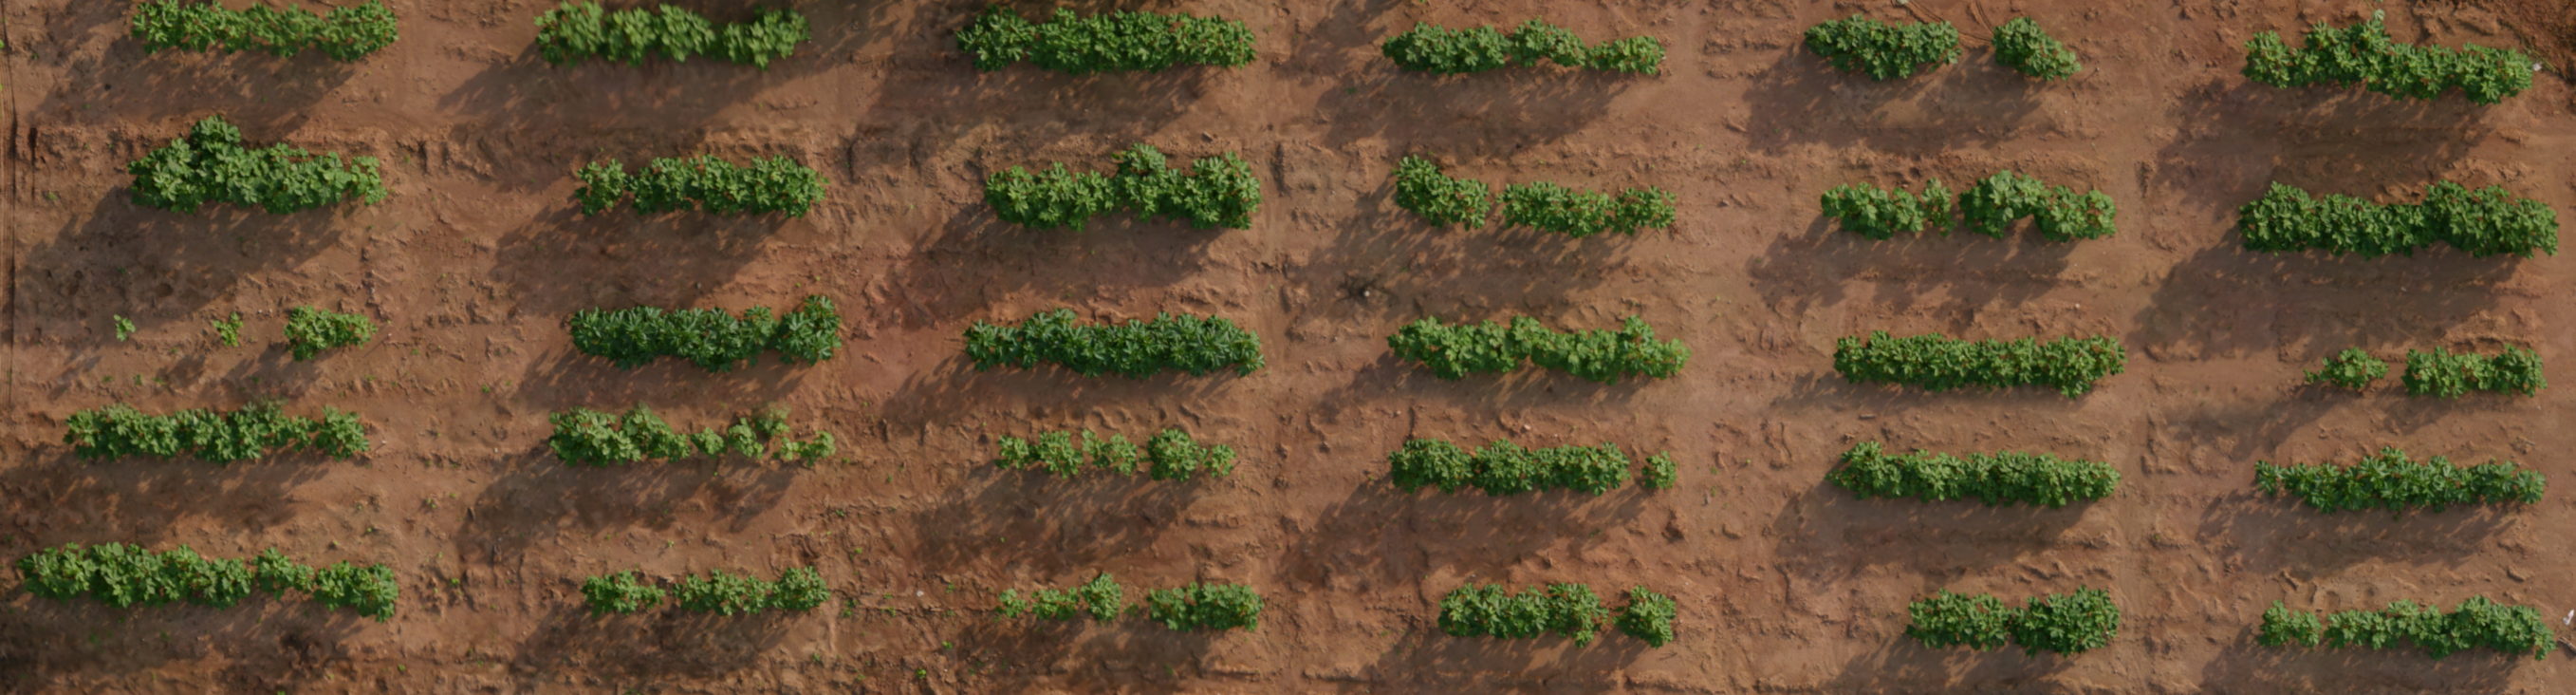

In [1]:
import cv2
from PIL import Image

# Load the image.
field_image = cv2.imread("2022-e-field.png")
field_image = cv2.cvtColor(field_image, cv2.COLOR_BGR2RGB)
display(Image.fromarray(field_image))

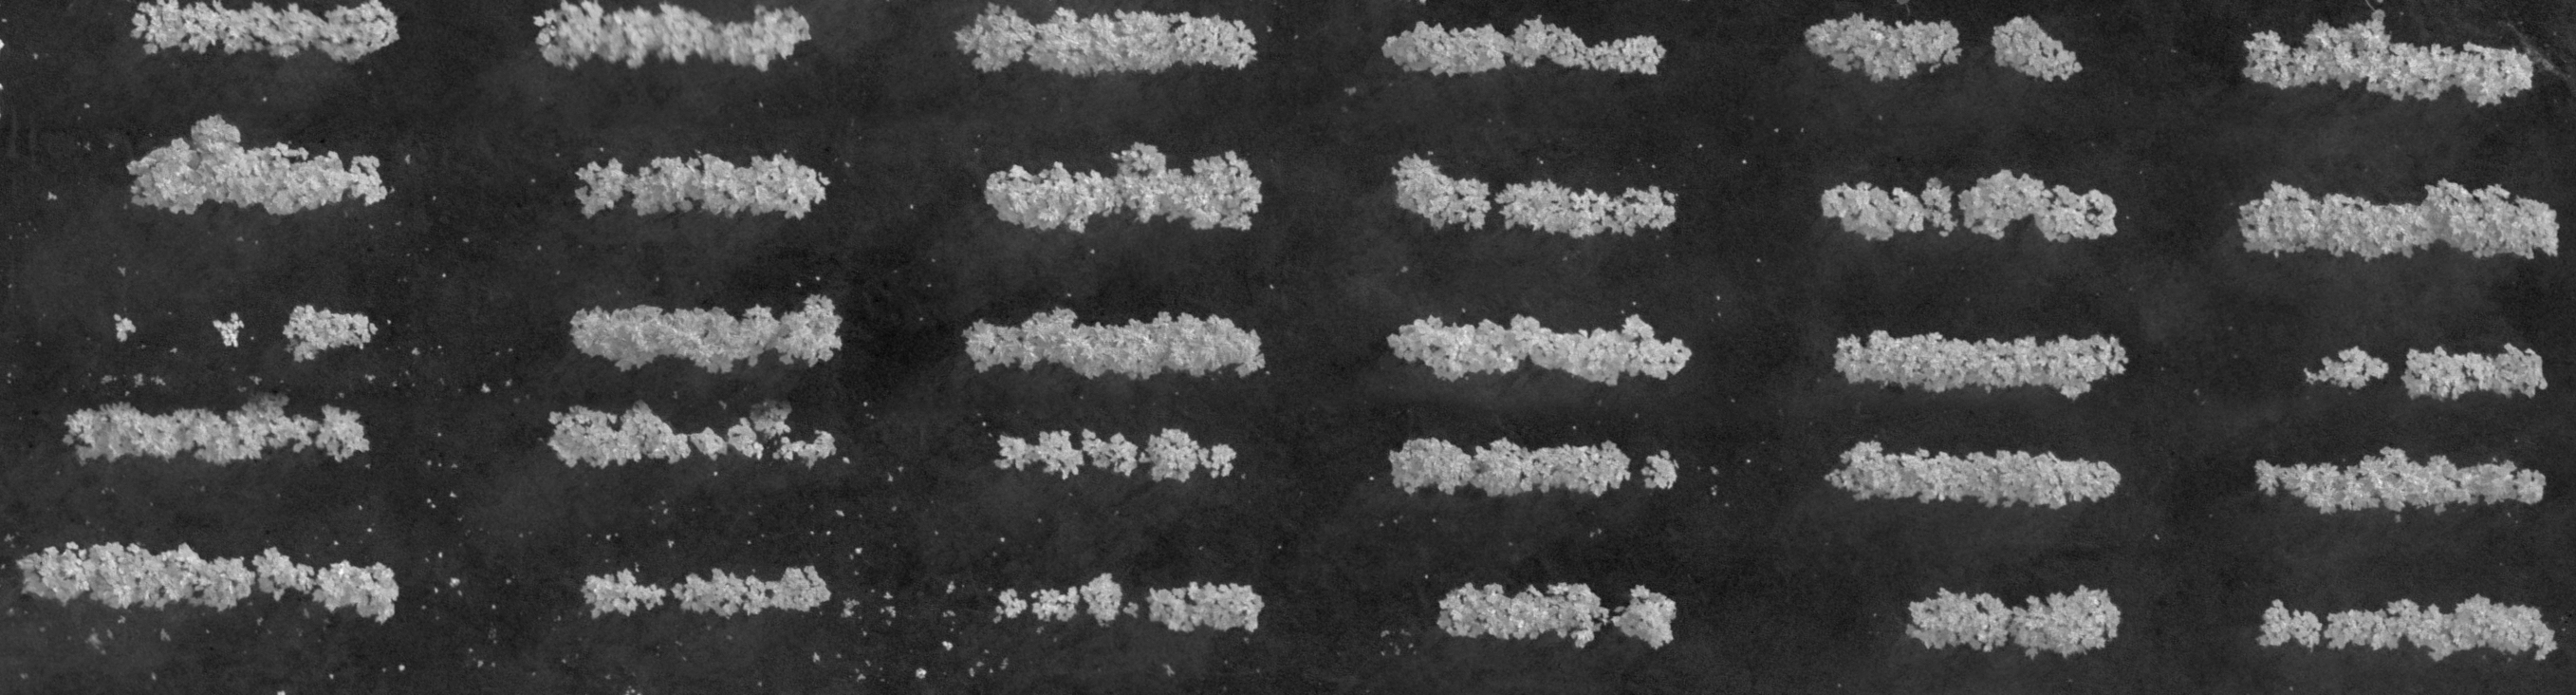

In [2]:
import numpy as np

# Compute excess green mask.
field_float = field_image.astype(np.float32)
r = field_float[..., 0]
g = field_float[..., 1]
b = field_float[..., 2]
excess_green = 2 * g - r - b
excess_green -= excess_green.min()
excess_green /= excess_green.max()
excess_green = (excess_green * 255).astype(np.uint8)

# Display the excess green.
display(Image.fromarray(excess_green))

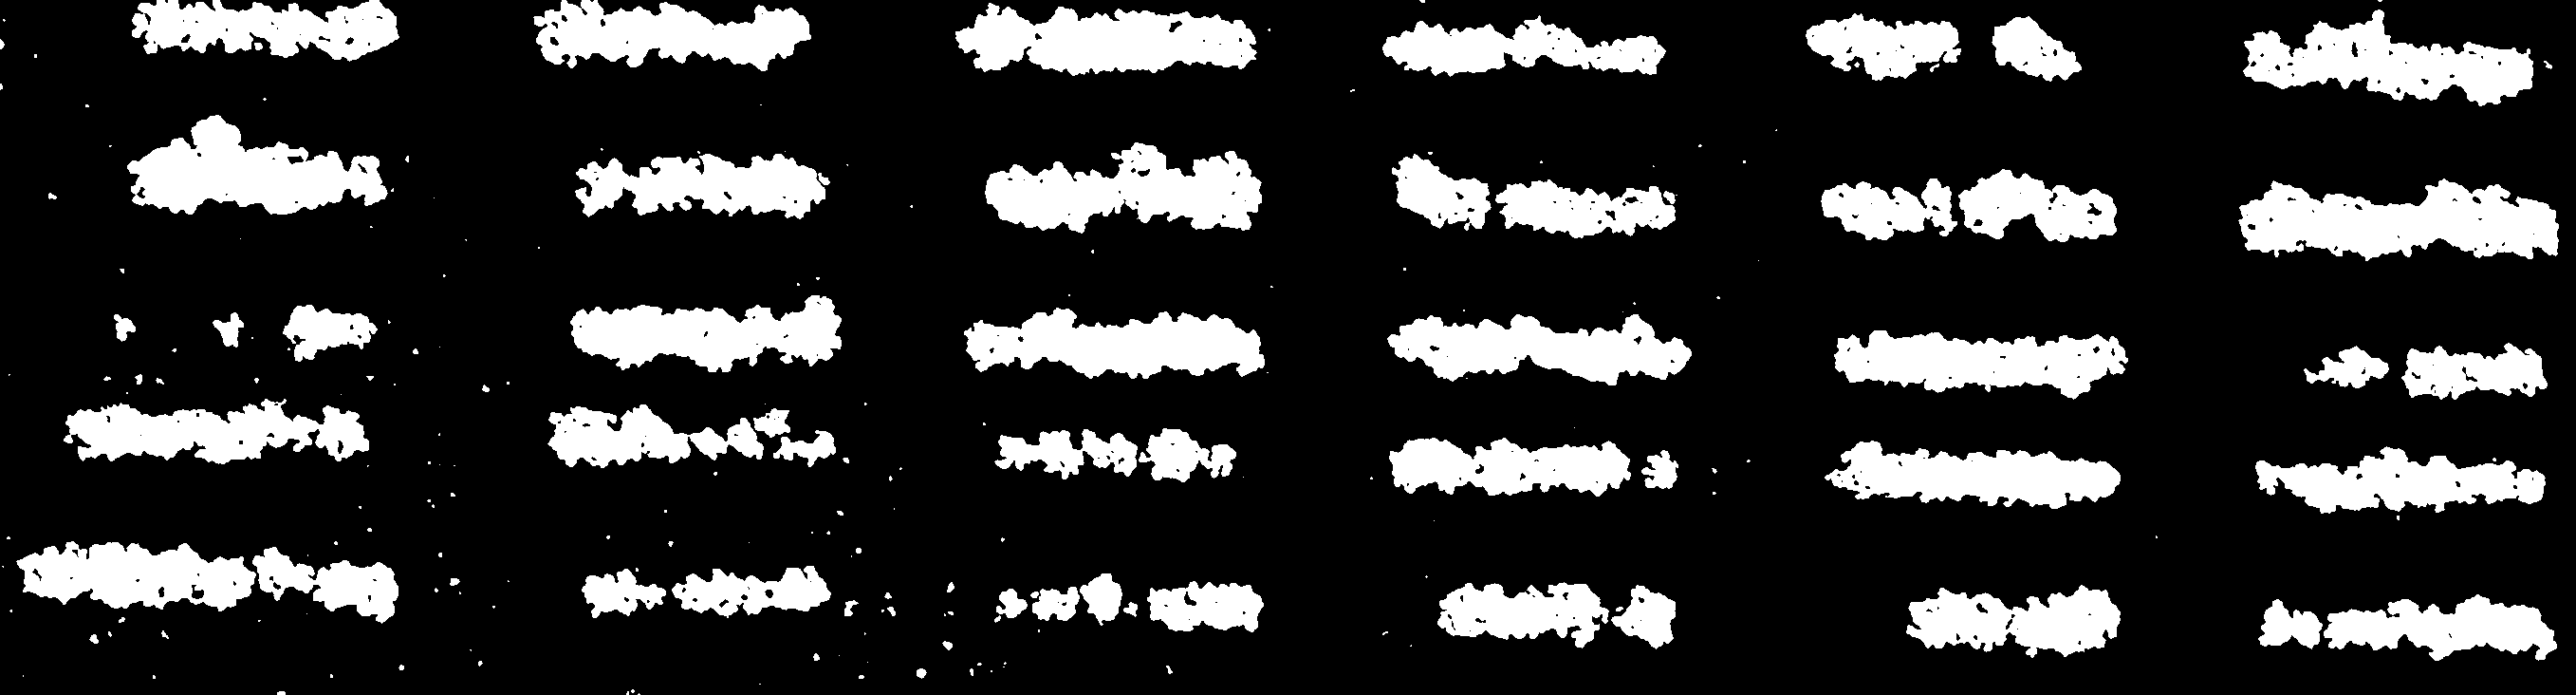

In [3]:
# Binarize the excess green.
excess_green_blur = cv2.GaussianBlur(excess_green, (5, 5), 0)
_, excess_green_bin = cv2.threshold(excess_green_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

display(Image.fromarray(excess_green_bin))

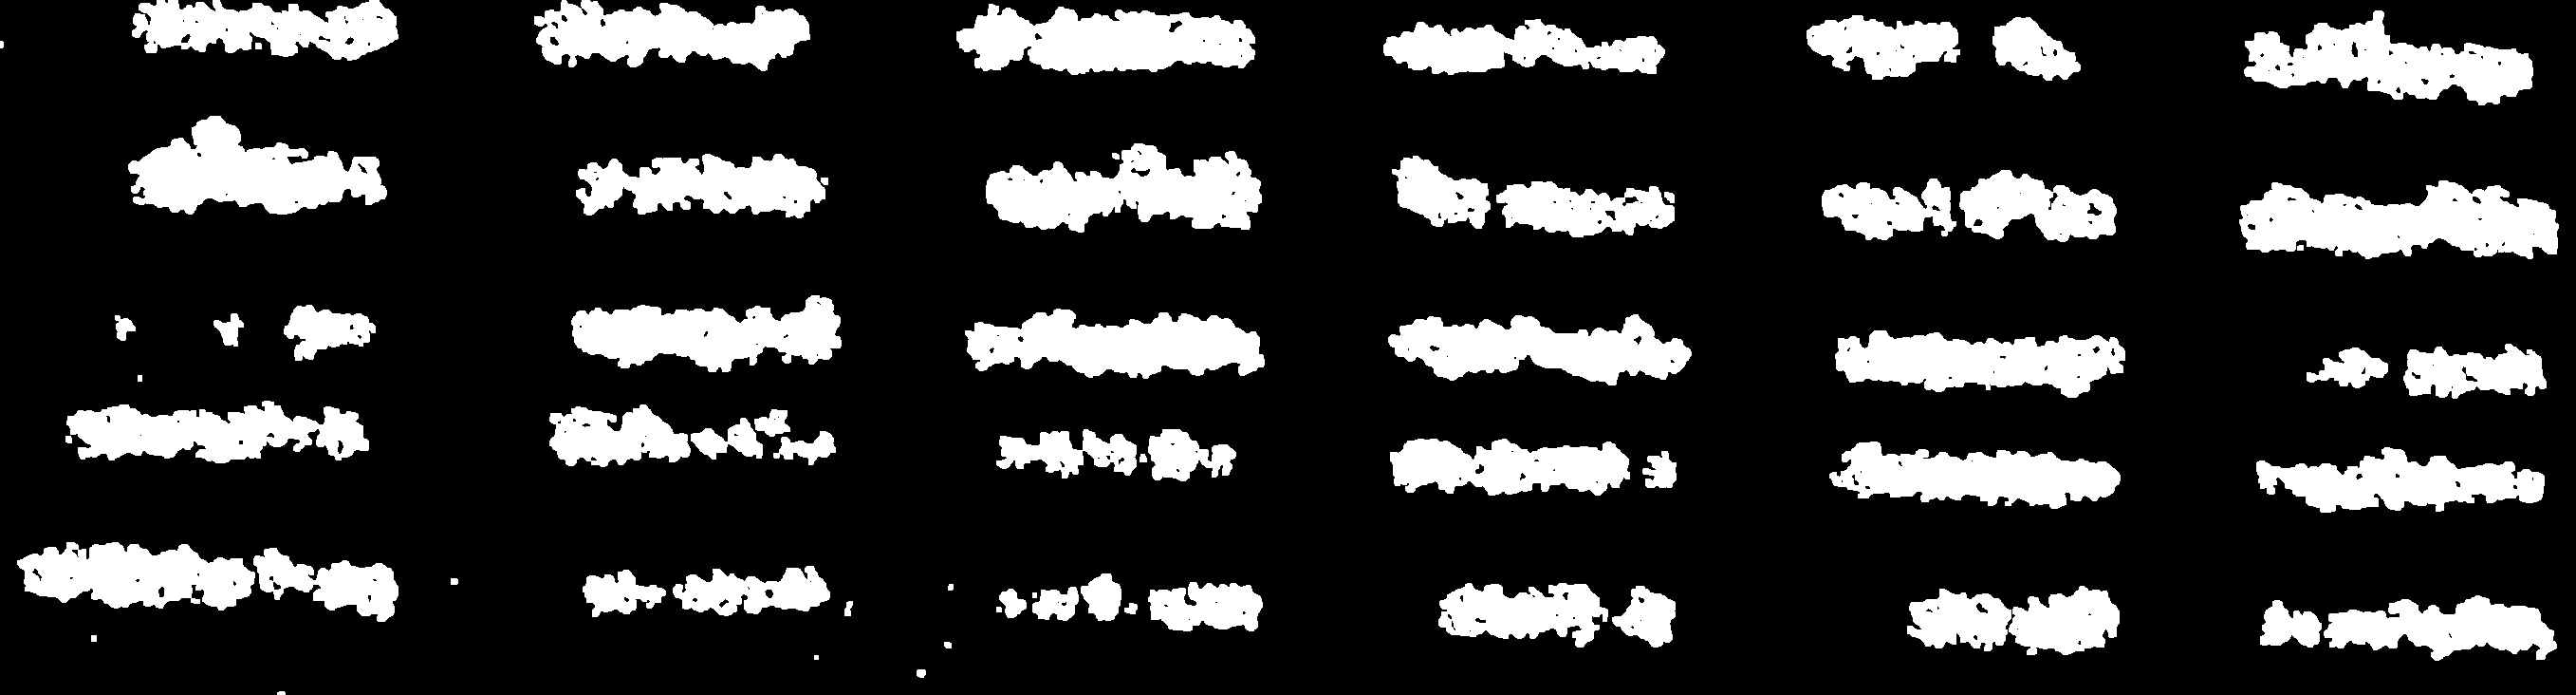

In [4]:
# Open to remove noise.
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
excess_green_denoised = cv2.morphologyEx(excess_green_bin, cv2.MORPH_OPEN, kernel)

display(Image.fromarray(excess_green_denoised))

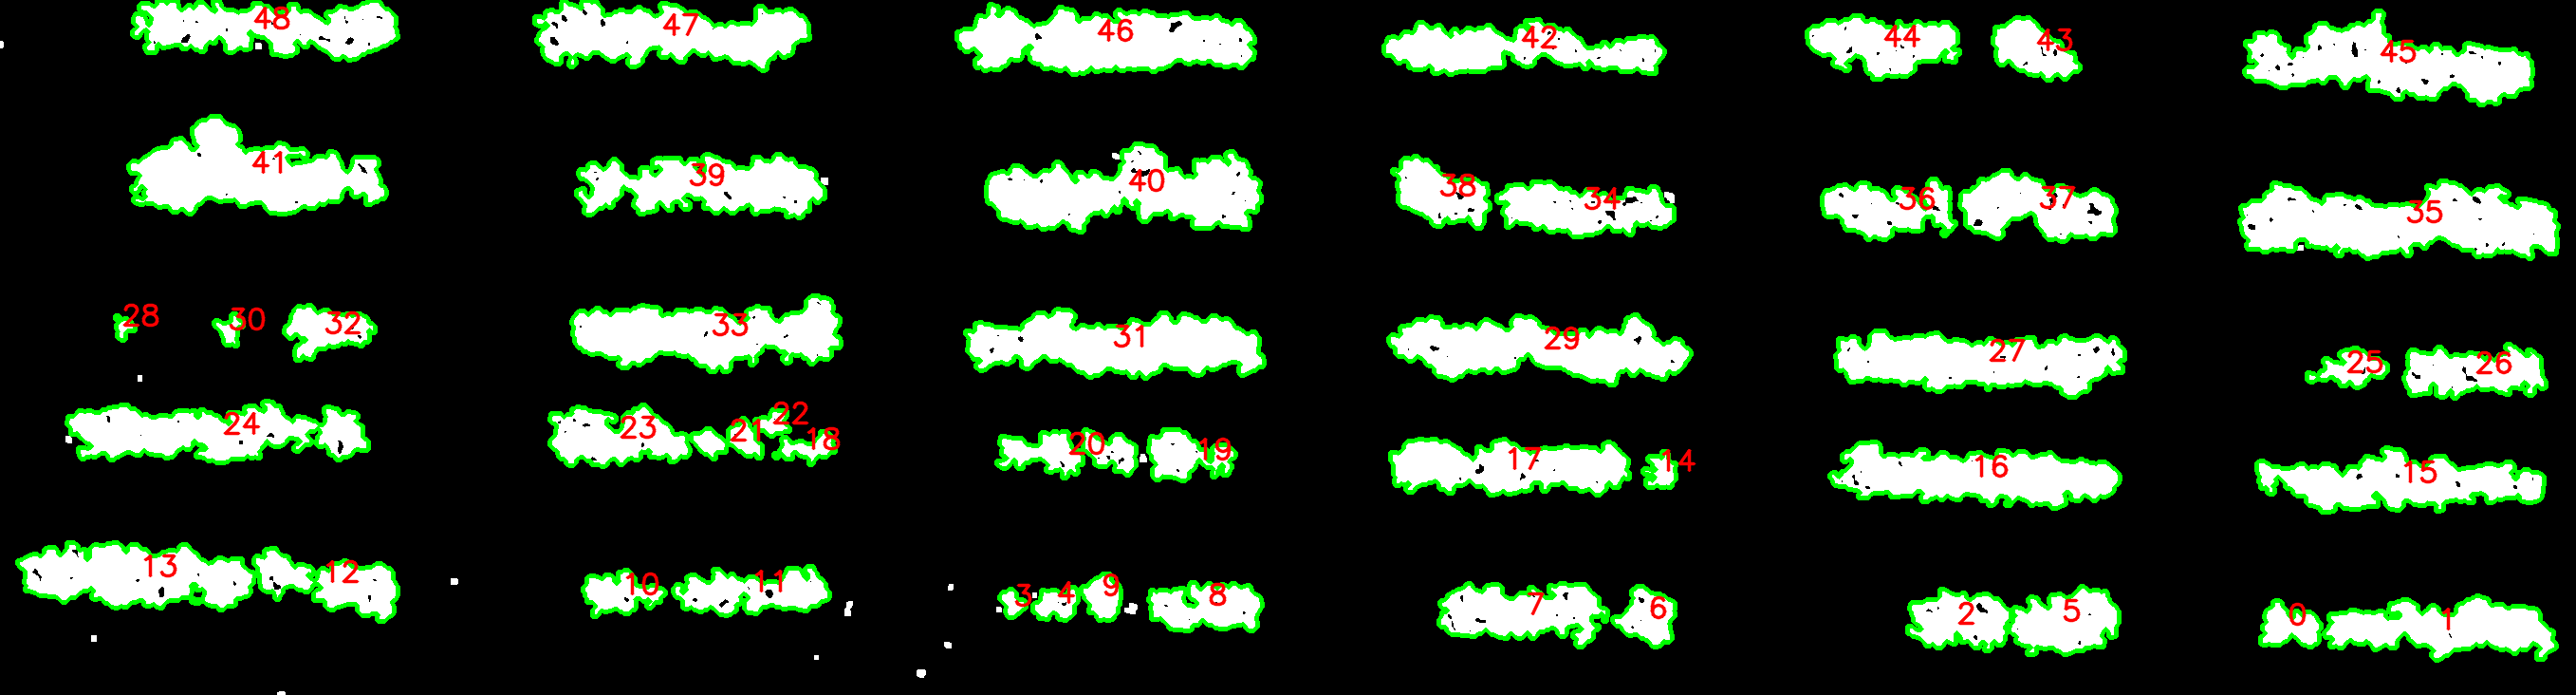

In [5]:
# Find contours.
contours, _ = cv2.findContours(excess_green_denoised, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
# Remove small ones.
big_contours = list(filter(lambda c: cv2.contourArea(c) > 100, contours))

contour_output = cv2.drawContours(np.stack([excess_green_denoised] * 3, axis=2), big_contours, -1, (0, 255, 0), 3)

# Assign numbers to each contour.
for i, contour in enumerate(big_contours):
    contour = np.squeeze(contour)
    centroid = np.mean(contour, axis=0).astype(int)
    cv2.putText(contour_output, str(i), centroid, cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2, cv2.LINE_AA)

display(Image.fromarray(contour_output))

In [7]:
# This is the association between plot numbers and contour numbers.
plots_to_contour = [
    # Row 1
    [48], [47], [46], [42], [44, 43], [45],
    # Row 2
    [35], [36, 37], [38, 34], [40], [39], [41],
    # Row 3
    [28, 30, 32], [33], [31], [29], [27], [25, 26],
    # Row 4
    [15], [16], [17, 14], [20, 19], [23, 21, 22, 18], [24],
    # Row 5
    [13, 12], [10, 11], [4, 3, 9, 8], [7, 6], [2, 5], [0, 1]
]

# Load the count data.
%reload_kedro
engr_counts = catalog.load("2022_engr_field_counts")["Predicted"]
engr_counts

2024-06-24 16:23:10,127 - kedro.ipython - INFO - Resolved project path as: /home/daniel/git/cotton_flower_mot.
To set a different path, run '%reload_kedro <project_root>'
2024-06-24 16:23:10,139 - py.warnings - WARNING - /home/daniel/git/cotton_flower_mot/.venv/lib/python3.10/site-packages/kedro/framework/startup.py:99: KedroDeprecationWarning: project_version in pyproject.toml is deprecated, use kedro_init_version instead
  warnings.warn(

2024-06-24 16:23:10,274 - py.warnings - WARNING - /home/daniel/git/cotton_flower_mot/.venv/lib/python3.10/site-packages/kedro/framework/session/session.py:267: KedroDeprecationWarning: TemplatedConfigLoader will be deprecated in Kedro 0.19. Please use the OmegaConfigLoader instead. To consult the documentation for OmegaConfigLoader, see here: https://docs.kedro.org/en/stable/configuration/advanced_configuration.html#omegaconfigloader
  warnings.warn(

2024-06-24 16:23:10,363 - py.warnings - WARNING - /home/daniel/git/cotton_flower_mot/.venv/lib/pyth


0      8
1     11
2      9
3      6
4     12
5     13
6     36
7      3
8     13
9      6
10    10
11     8
12     3
13     8
14    15
15     9
16    27
17     7
18    10
19     6
20    19
21     9
22     1
23     9
24    11
25     5
26     8
27    14
28     9
29     7
Name: Predicted, dtype: int64

In [8]:
from PIL import ImageDraw, ImageFont
from typing import Tuple, Iterable

START_COLOR = [255, 255, 255]
END_COLOR = [130, 19, 87]

KEY_FONT = ImageFont.truetype("../fonts/VeraBd.ttf", 24)
TITLE_FONT = ImageFont.truetype("../fonts/VeraBd.ttf", 48)

# Compute normalized count values.
engr_counts_norm = engr_counts / engr_counts.max().max()

def get_color(count_norm: float) -> Tuple[int, int, int]:
    # Gets the RGB color value for a particular normalized count.
    color = []
    for i in range(len(START_COLOR)):
        color.append(np.interp(count_norm, [0.0, 1.0], [START_COLOR[i], END_COLOR[i]]))
    return tuple([int(c) for c in color])


def draw_key() -> Image.Image:
    # Draws the key to use.
    key_height = field_image.shape[0]
    # Generate the gradient.
    gradient = np.linspace(END_COLOR, START_COLOR, key_height).astype(np.uint8)
    gradient = gradient.reshape((-1, 1, 3))
    gradient = np.tile(gradient, (1, 50, 1))
    gradient = Image.fromarray(gradient)
    
    key = Image.new("RGB", (100, field_image.shape[0]), color=(255, 255, 255))
    key.paste(gradient, (0, 0))
    
    # Draw the markings.
    artist = ImageDraw.Draw(key)
    regular_counts = np.linspace(0, engr_counts.max().max(), 10).astype(int)
    regular_counts_y = np.linspace(key_height, 0, 10).astype(int)
    for y, count in zip(regular_counts_y, regular_counts):
        artist.text((60, y), str(count), fill=(50, 50, 50), font=KEY_FONT)
    
    return key


figure_key = draw_key()
    

def draw_figure(counts: Iterable[float], title: str = "Plot Counts") -> Image.Image:
    figure = Image.fromarray(np.ones_like(field_image) * 255)
    artist = ImageDraw.Draw(figure)
    
    for count, contour_idxs in zip(counts, plots_to_contour):
        color = get_color(count)
        for contour_i in contour_idxs:
            contour = big_contours[contour_i]
            # Draw the contour in the correct color.
            artist.polygon(contour.flatten().tolist(), fill=color, outline=(50, 50, 50))
        
    # Box the plots.
    artist.rectangle([0, 0, figure.width, figure.height], outline=(50, 50, 50), width=2)
    # Add the key.
    figure_with_key = Image.new("RGB", (figure.width + 50 + figure_key.width, figure.height + 100), color=(255, 255, 255))
    figure_with_key.paste(figure, (0, 100))
    figure_with_key.paste(figure_key, (figure.width + 50, 100))
    
    # Add the title.
    artist = ImageDraw.Draw(figure_with_key)
    artist.text((figure_with_key.width / 2, 50), title, fill=(50, 50, 50), font=TITLE_FONT, anchor="mm") 
    
    return figure_with_key
        

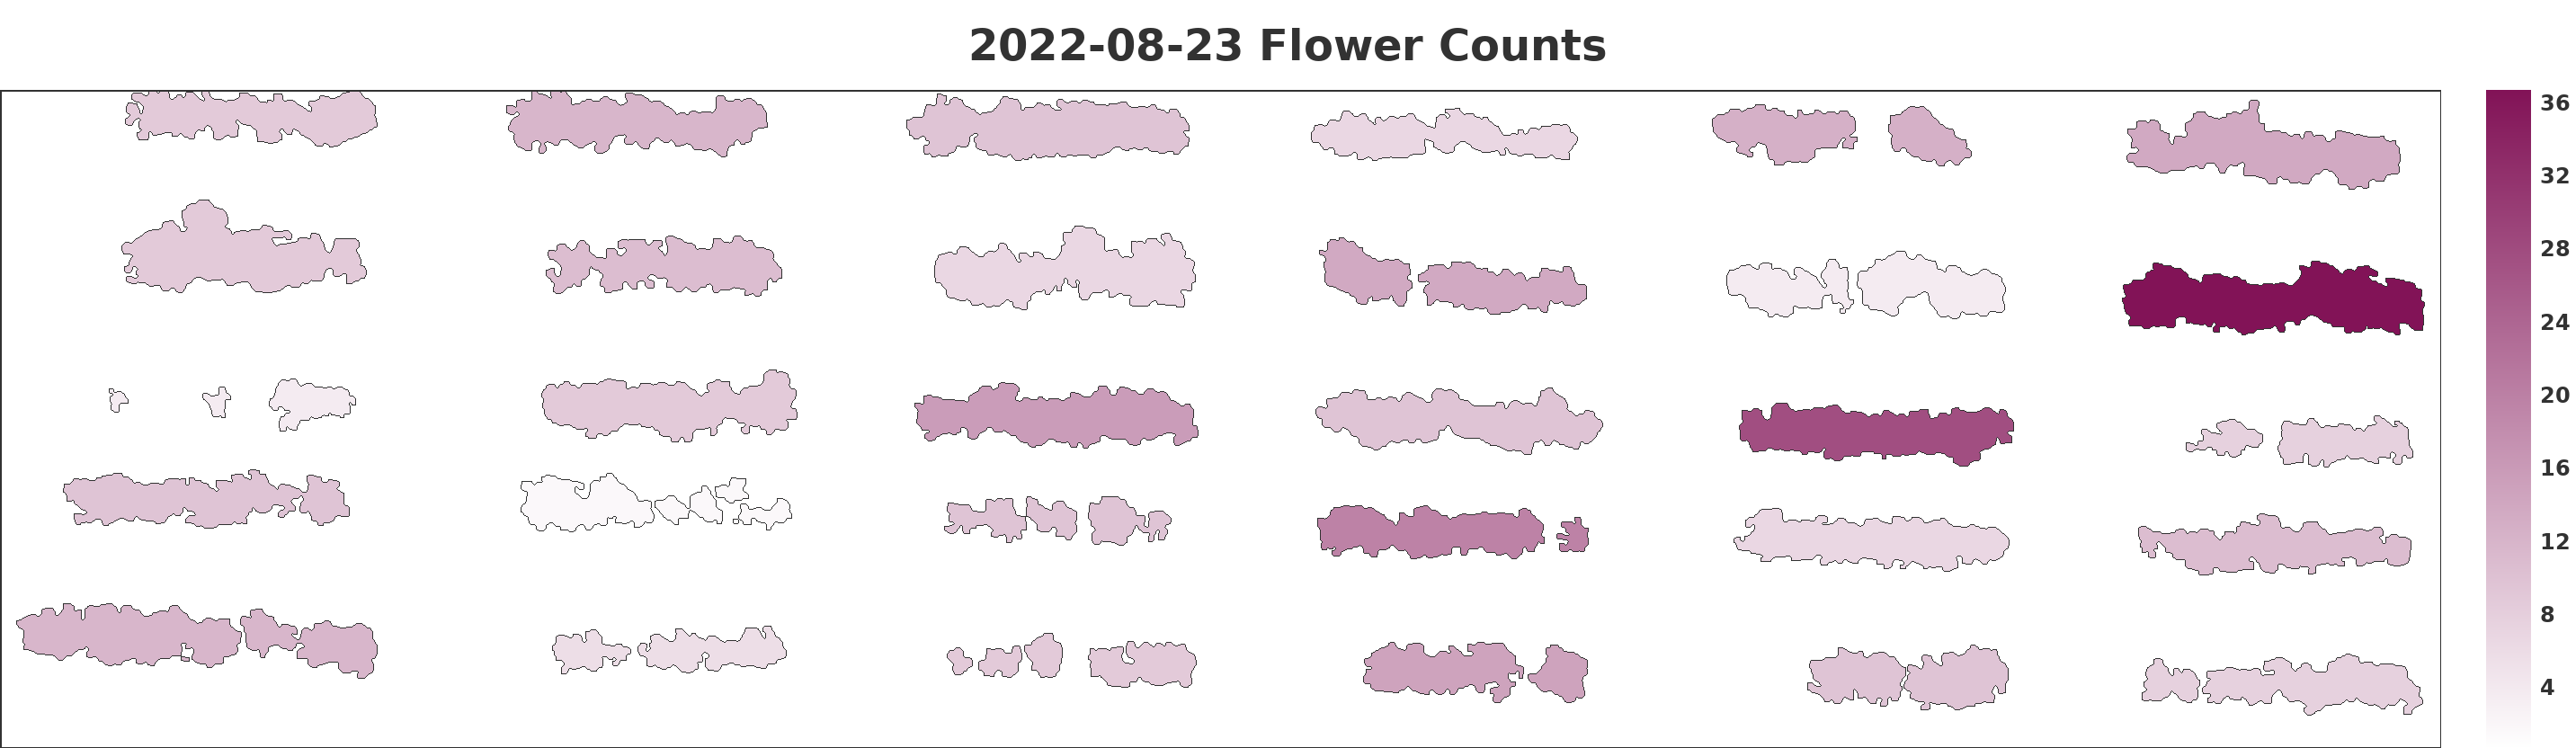

In [9]:
figure_8_23 = draw_figure(engr_counts_norm, title="2022-08-23 Flower Counts")
display(figure_8_23)

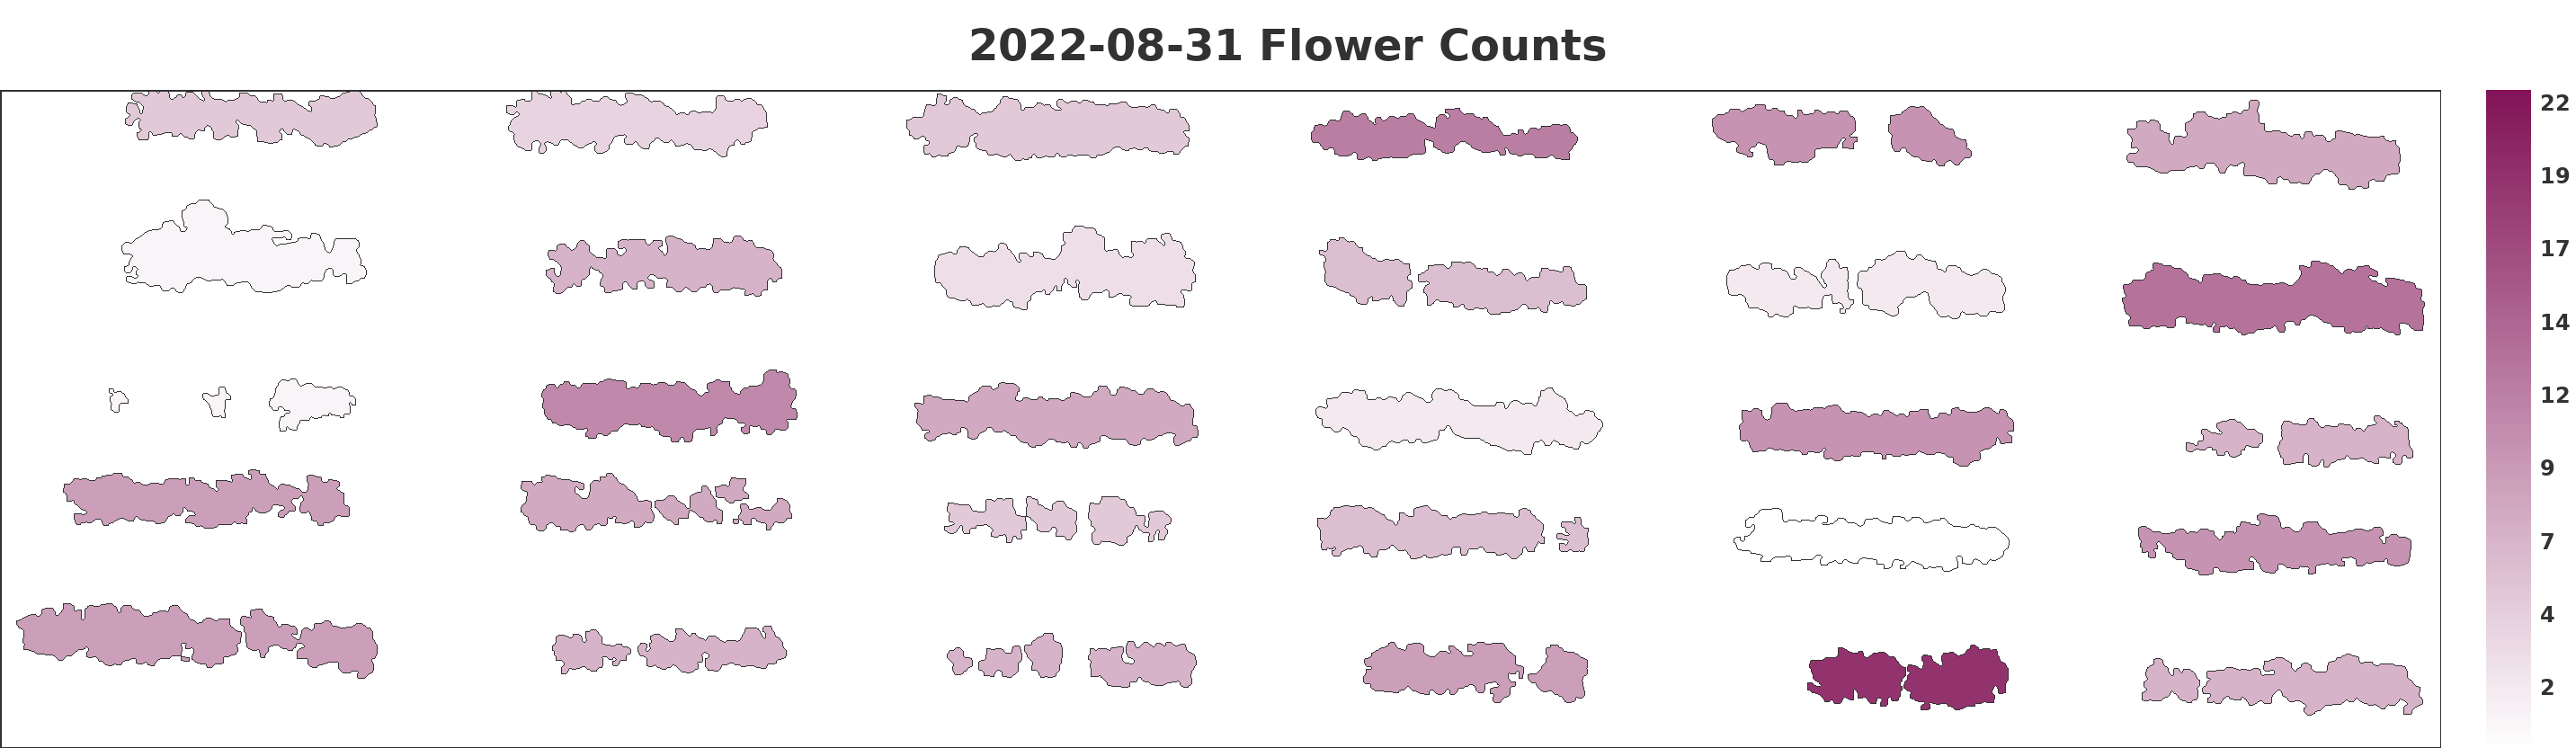

In [19]:
figure_8_31 = draw_figure(engr_counts_norm["2022-08-31"], title="2022-08-31 Flower Counts")
display(figure_8_31)

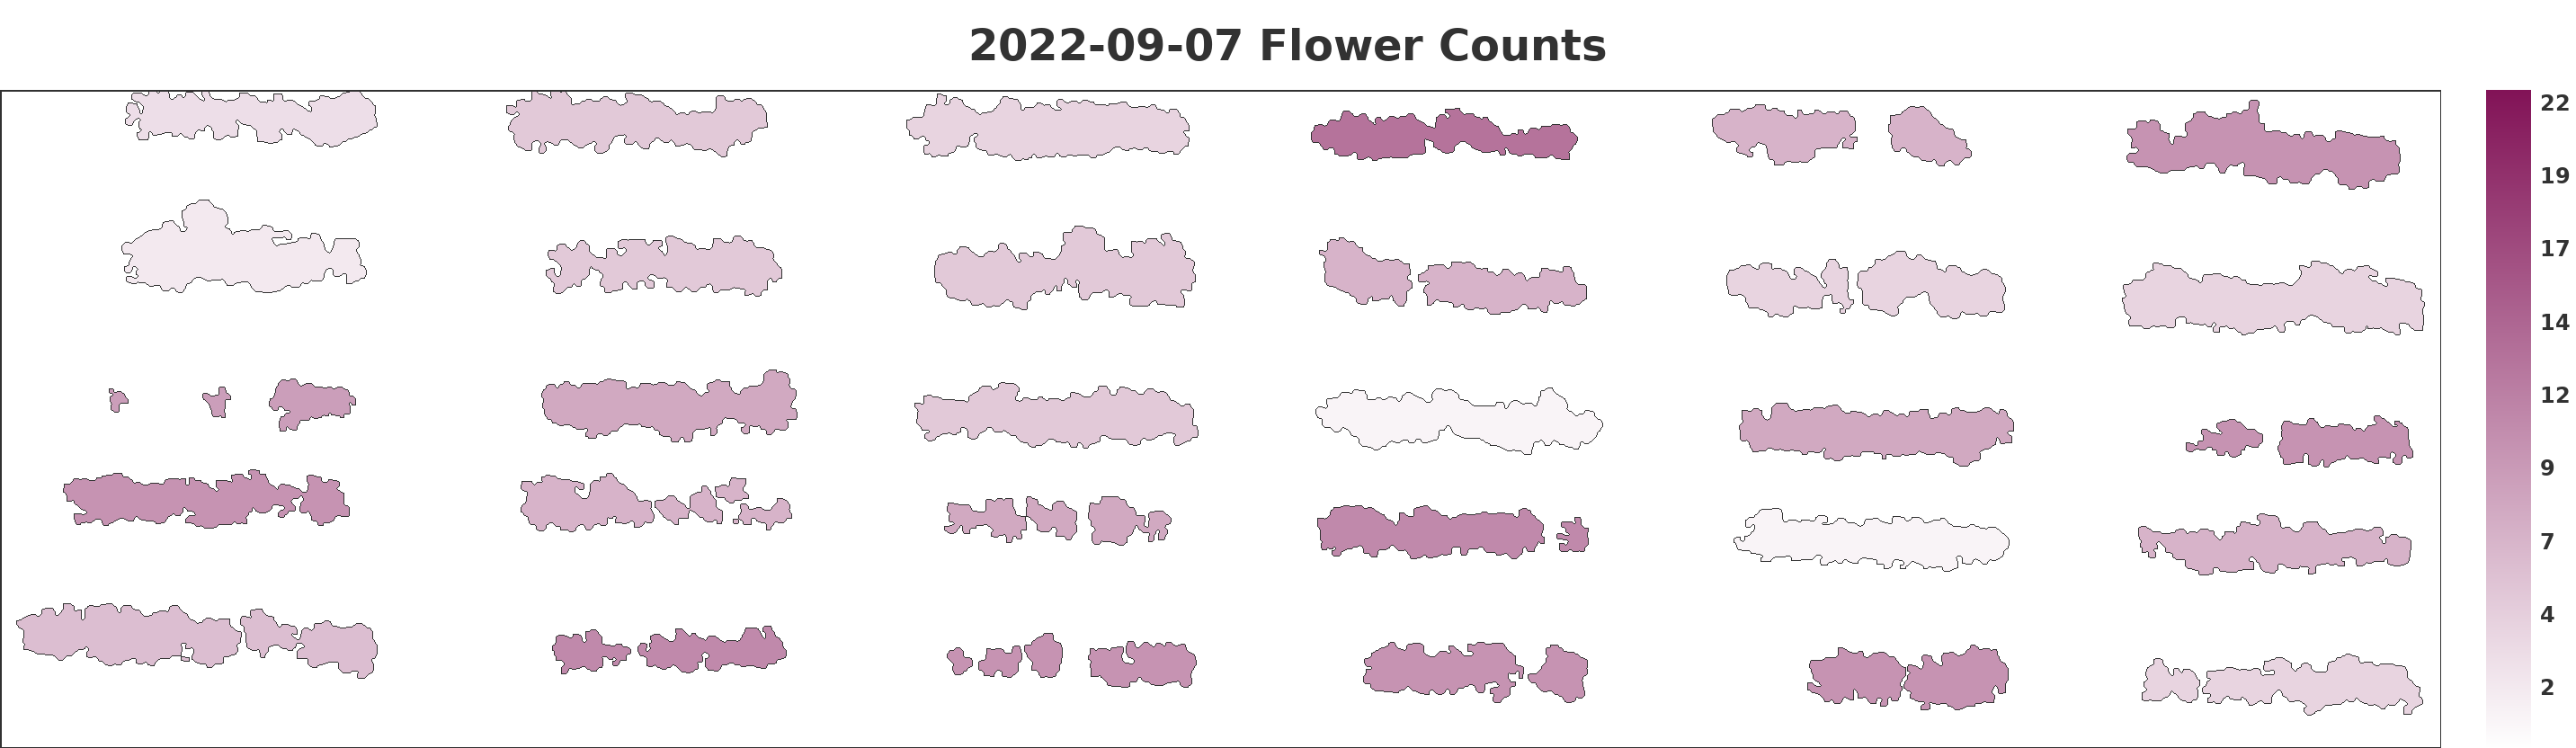

In [20]:
figure_9_07 = draw_figure(engr_counts_norm["2022-09-07"], title="2022-09-07 Flower Counts")
display(figure_9_07)

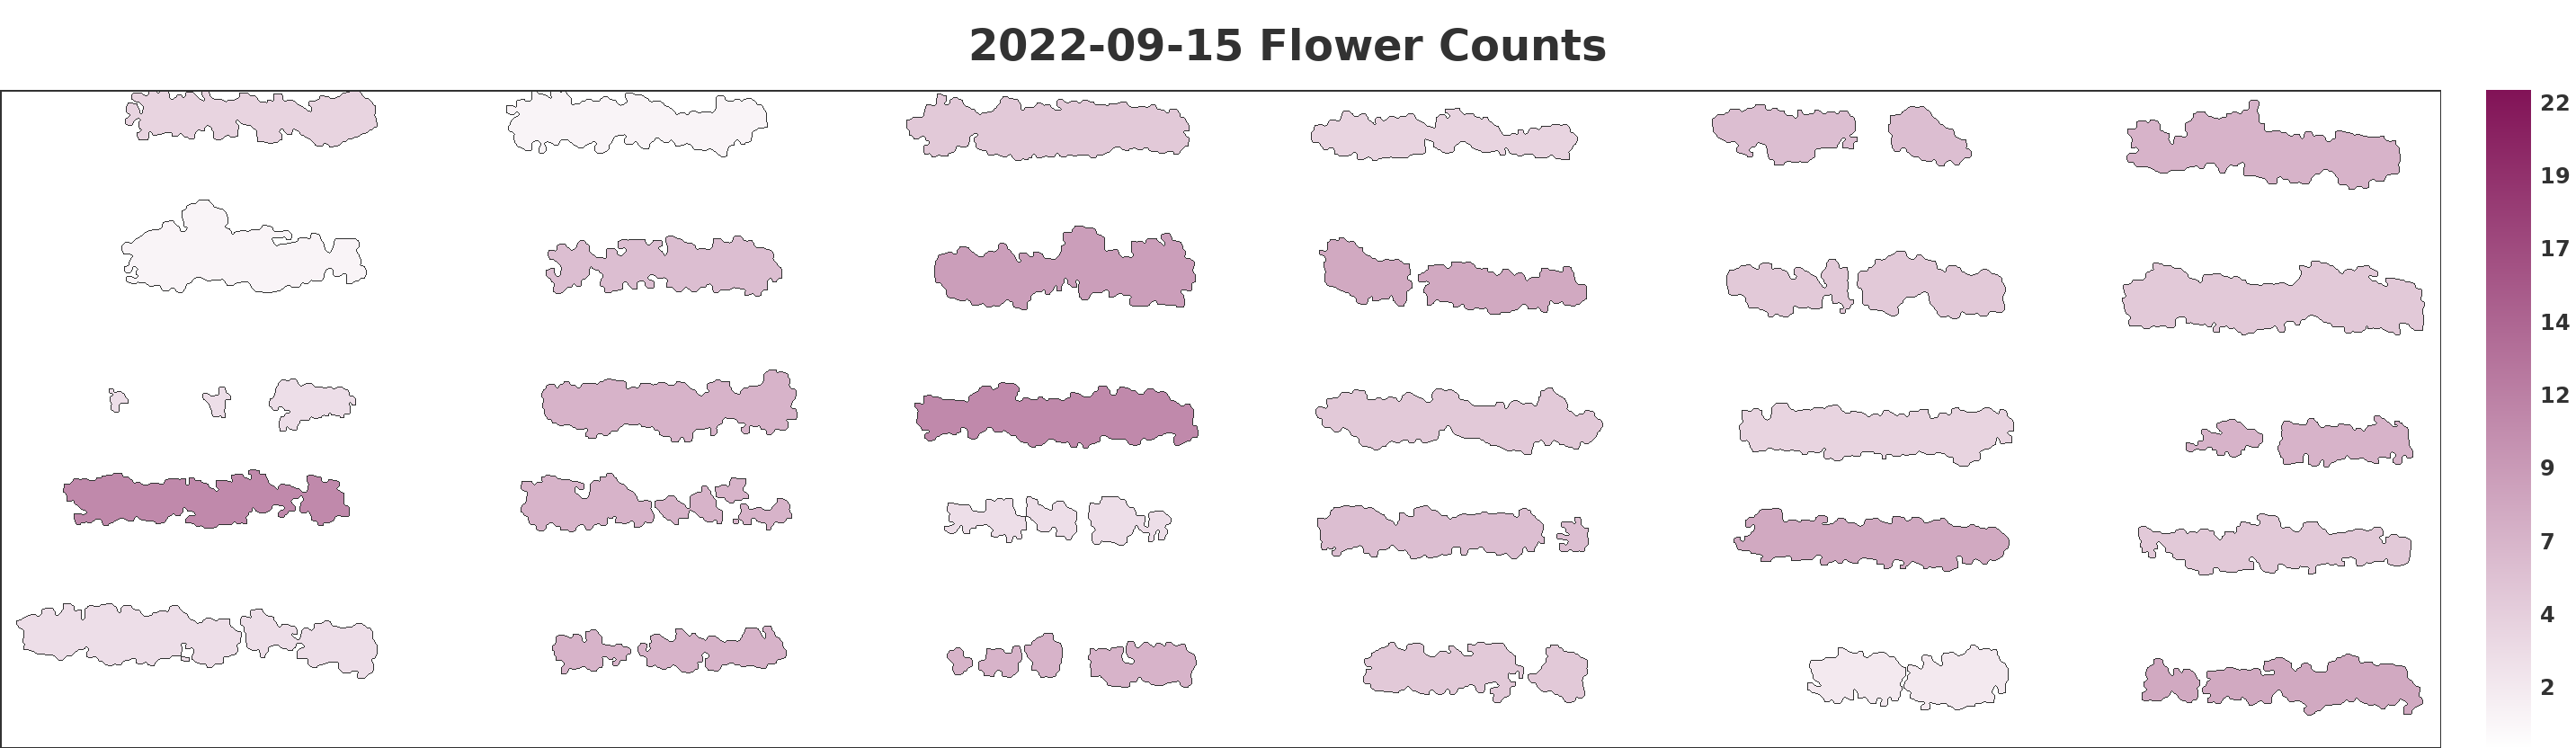

In [21]:
figure_9_15 = draw_figure(engr_counts_norm["2022-09-15"], title="2022-09-15 Flower Counts")
display(figure_9_15)